# Corn NIR across three instruments: groups, ranges, and the MNAR alarm

The Eigenvector corn set: the SAME 80 samples measured on three NIR
instruments (m5, mp5, mp6), 700 channels (1100 to 2498 nm), four property
targets. This is the notebook for RSM's instrument-aware machinery:

1. grouped cross-validation (a physical sample must never span a split),
2. instrument-range missingness as a validity mask, with honest refusals,
3. the MNAR guard, quiet when ranges are benign and loud when the
   observation pattern tracks the target, and how imputation would have
   destroyed that alarm.

The range scenario below is IMPOSED (the real corn data is complete), and
labelled as such throughout; imposing it on real spectra is what lets every
claim be checked against the complete-data reference.

In [1]:
import sys
sys.path.insert(0, "../benchmarks")
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_corn

X, V, y, meta = load_corn(instrument="all", target="Moisture")
groups = meta["groups"]           # 0=m5, 1=mp5, 2=mp6; same 80 samples each
sample_id = np.tile(np.arange(80), 3)   # the PHYSICAL sample identity
wavelength = np.linspace(1100, 2498, 700)
print(X.shape, meta["note"])

(240, 1, 700) 80 physical samples repeated per instrument; use groups


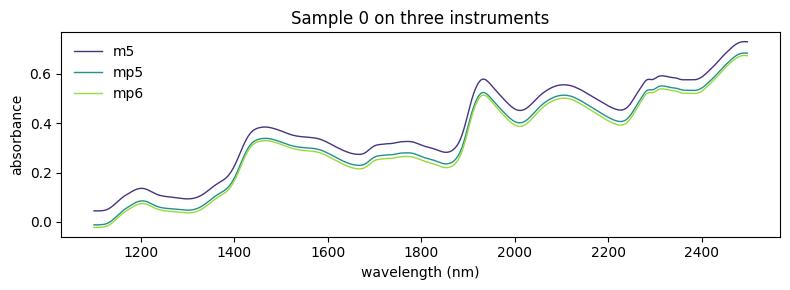

In [2]:
# one sample through three instruments: the instrument effect is real
fig, ax = plt.subplots(figsize=(8, 3))
shades = [0.15, 0.5, 0.85]
for g, name, s in zip(range(3), ("m5", "mp5", "mp6"), shades):
    row = np.flatnonzero((groups == g) & (sample_id == 0))[0]
    ax.plot(wavelength, X[row, 0], color=plt.cm.viridis(s), lw=1, label=name)
ax.set_xlabel("wavelength (nm)")
ax.set_ylabel("absorbance")
ax.legend(frameon=False)
ax.set_title("Sample 0 on three instruments")
plt.tight_layout()

## Grouped nested CV

With all three instruments stacked, the same physical sample exists three
times. Passing the PHYSICAL sample id as `groups` guarantees no sample ever
sits on both sides of a split; forgetting this would leak identity and
flatter every score.

In [3]:
from robustsignalmaker import NestedCV

eng = NestedCV(k_outer=5, segment=20, lam=0.08, n_bootstrap=25,
               target_coverage=5 / 35, random_state=0)
res = eng.run(X, y, groups=sample_id)
s = res.summary()
{k: s[k] for k in ("score_name", "score_mean", "verdict",
                    "baseline_score_mean", "selection_stability_adjusted",
                    "grouped")}

{'score_name': 'RMSE',
 'score_mean': 0.25595947313432693,
 'verdict': 'preserved',
 'baseline_score_mean': 0.18374094403085972,
 'selection_stability_adjusted': 0.5014741888935438,
 'grouped': True}

In [4]:
# where the bands landed. Spoiler from the benchmarks: with the default
# mean lens two of the four sit at the spectrum EDGES (scatter, not
# chemistry) alongside two water bands; the
# lens section at the end of this notebook is the other half of this story
final = res.final_estimator.selector_
print("selected segments:", final.selected_segments_)
for seg in final.selected_segments_:
    pts = final.grid.segments_to_points([seg])
    print(f"  segment {seg}: {wavelength[pts[0]]:.0f} to {wavelength[pts[-1]]:.0f} nm")

selected segments: [ 7 19 33 34]
  segment 7: 1380 to 1418 nm
  segment 19: 1860 to 1898 nm
  segment 33: 2420 to 2458 nm
  segment 34: 2460 to 2498 nm


## Instrument ranges as validity (imposed scenario)

Now the RSM-specific case: suppose mp6 never measured above 2100 nm and mp5
never below 1300 nm (imposed here, labelled as such). The mask travels with
the data; segments outside an instrument's range contribute nothing for its
samples, support is reported beside every frequency, and the guard checks
whether the observation pattern is confounded with the target.

In [5]:
from robustsignalmaker import mask_band_by_group, BootstrapMaskSelector

hi = int(np.searchsorted(wavelength, 2100.0))
lo = int(np.searchsorted(wavelength, 1300.0))
V_range = mask_band_by_group(X.shape, groups, {2: [(hi, 700)], 1: [(0, lo)]})
sel = BootstrapMaskSelector(task="regression", segment=20, lam=0.08,
                            n_bootstrap=25, target_coverage=5 / 35,
                            seed=0).fit(np.where(V_range, X, np.nan), y,
                                        V_range, obs_groups=groups)
rep = sel.stability_report()
print("strata:", rep["strata"])
print("unassessable fraction:", rep["unassessable_fraction"])
print("selected:", sel.selected_segments_)
print("verdicts of the last four segments (mp6 never sees them):",
      sel.verdicts_[-4:], " support:", np.round(sel.support_[-4:], 2))

strata: stratified by observation group
unassessable fraction: 0.0
selected: [ 6  7 23 24 34]
verdicts of the last four segments (mp6 never sees them): ['rejected' 'rejected' 'rejected' 'selected']  support: [1. 1. 1. 1.]


In [6]:
# honest refusal: a spectrum observed only where nothing was selected
X_probe = X[:2].copy()
V_probe = np.zeros_like(X_probe, dtype=bool)
V_probe[0] = True                 # fully observed: scored
V_probe[1, :, :40] = True         # a sliver: refused, not guessed
print("prediction:", sel.predict(X_probe, V_probe))
print("valid:", sel.model_.prediction_valid(X_probe, V_probe))

prediction: [10.3293109        nan]
valid: [ True False]


## The alarm, and what imputation does to it

Ranges tied to instruments are benign here (instruments are unrelated to
moisture), so the guard has nothing to flag. Tie the missing range to the
TARGET
instead (wet samples lose the long-wavelength end, the kind of thing a
detector limit can do) and the guard fires and names the bands. Fill the
gaps first, and there is nothing left for any guard to test: the fabricated
dataset looks complete and innocent.

In [7]:
import warnings
from robustsignalmaker import SegmentGrid, missingness_association

grid = SegmentGrid(700, segment=20)
wet = (y > np.median(y)).astype(int)   # imposed: wet samples lose the far end
V_mnar = mask_band_by_group(X.shape, wet, {1: [(600, 700)]})
with warnings.catch_warnings(record=True):
    warnings.simplefilter("always")
    report = missingness_association(grid.segment_validity(V_mnar.astype(float)),
                                     y, "regression", n_permutations=60, seed=0)
print("masked pipeline verdict:", report["verdict"],
      " top segments:", report["top_segments"])

# after any imputation the validity pattern is gone: nothing to test
report_imputed = missingness_association(
    grid.segment_validity(np.ones_like(X)), y, "regression",
    n_permutations=60, seed=0)
print("after imputation the guard sees:", report_imputed["verdict"])

masked pipeline verdict: informative  top segments: [34 33 32 31 30]
after imputation the guard sees: not_informative


## Which bands "matter" depends on the lens: the marginalisation case

Benchmark finding B (benchmarks/FINDINGS.md sec.6): on corn the mean lens
takes BOTH spectrum edges, 1100 to 1138 and 2460 to 2498 nm, the classic
multiplicative-scatter signature of uncorrected NIR, while the derivative
lens takes neither and selects the water bands instead (the cell below
prints its five: 1420, 1900, 1940, 2020 and 2060 nm, so the 1450 nm water
overtone and the 1940 nm combination band). Measured lens agreement at these
settings: 0.205. Scatter correction is a lens decision, not neutral
preprocessing, and the ensemble is how RSM treats that decision as a
nuisance instead of defending one choice. Watch what the marginalised
selection does with the edges.

In [8]:
from robustsignalmaker import (RepresentationEnsembleSelector,
                               SavGolDerivative, default_ensemble)

Xm5, Vm5, ym5, _ = load_corn(instrument="m5")
kw = dict(task="regression", segment=20, lam=0.08, n_bootstrap=25,
          target_coverage=5 / 35, seed=0)
sg = BootstrapMaskSelector(representation=SavGolDerivative(), **kw).fit(Xm5, ym5, Vm5)
print("derivative lens selects:",
      [f"{wavelength[sg.grid.segments_to_points([s])[0]]:.0f} nm"
       for s in sg.selected_segments_])
ens = RepresentationEnsembleSelector(representations=default_ensemble(3, seed=0),
                                     **kw).fit(Xm5, ym5, Vm5)
print("lens agreement:", round(float(ens.representation_agreement()), 3))
print("marginalised selection:", ens.selected_segments_)

derivative lens selects: ['1420 nm', '1900 nm', '1940 nm', '2020 nm', '2060 nm']


lens agreement: 0.205
marginalised selection: [ 6  7  8 19 24]


The one-line summary for a report: grouped CV kept physical samples intact,
instrument-range gaps were carried as validity with support printed beside
every frequency, thin evidence was refused rather than guessed, the MNAR
alarm survives only in the pipeline that never fabricated a value, and the
water-band chemistry appears when the lens suppresses scatter, which is why
selection is marginalised over lenses rather than tied to one.